In [164]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.ensemble import RandomForestRegressor
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

import warnings
warnings.filterwarnings('ignore')

In [165]:
# Установка seed для воспроизводимости результатов
np.random.seed(42)
torch.manual_seed(42)

# Загрузка датасета ETTh2 (укажите ваш путь к файлу)
file_path = "ETTh2.csv"
df = pd.read_csv(file_path)

# Преобразование колонки date в формат datetime и установка её в качестве индекса
df['date'] = pd.to_datetime(df['date'])
df.set_index('date', inplace=True)

## Исследование данных

In [166]:
# 1. Описание датасета и признаков
print("=== ОПИСАНИЕ ПРИЗНАКОВ ДАТАСЕТА ===")
print(f"Общее количество строк (измерений): {df.shape[0]}")
print(f"Количество признаков: {df.shape[1]}")

print("Первые 5 строк датасета")
print(df.head())

print("\nИнформация о датасете")
print(df.info())

print("\nБазовая статистика")
print(df.describe())

=== ОПИСАНИЕ ПРИЗНАКОВ ДАТАСЕТА ===
Общее количество строк (измерений): 17420
Количество признаков: 7
Первые 5 строк датасета
                          HUFL    HULL       MUFL   MULL   LUFL   LULL  \
date                                                                     
2016-07-01 00:00:00  41.130001  12.481  36.535999  9.355  4.424  1.311   
2016-07-01 01:00:00  37.528000  10.136  33.936001  7.532  4.435  1.215   
2016-07-01 02:00:00  37.946999  11.309  35.330002  9.007  2.100  0.000   
2016-07-01 03:00:00  38.952000  11.895  35.543999  9.436  3.380  1.215   
2016-07-01 04:00:00  38.113998  11.476  35.410000  9.623  2.036  0.000   

                            OT  
date                            
2016-07-01 00:00:00  38.661999  
2016-07-01 01:00:00  37.124001  
2016-07-01 02:00:00  36.465000  
2016-07-01 03:00:00  33.608501  
2016-07-01 04:00:00  31.850500  

Информация о датасете
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 17420 entries, 2016-07-01 00:00:00 to 2018-06-26

Обозначения полей:
- date: Дата и время записи (Индекс)
- HUFL: High UseFul Load (Высокая полезная нагрузка)
- HULL: High UseLess Load (Высокая бесполезная нагрузка)
- MUFL: Middle UseFul Load (Средняя полезная нагрузка)
- MULL: Middle UseLess Load (Средняя бесполезная нагрузка)
- LUFL: Low UseFul Load (Низкая полезная нагрузка)
- LULL: Low UseLess Load (Низкая бесполезная нагрузка)
- OT (Target): Oil Temperature (Температура масла - целевая переменная)

## Анализ ряда (EDA)

In [167]:
# 2. Проверка ВСЕХ временных рядов на стационарность (тест Дики-Фуллера)
print("=== АНАЛИЗ СТАЦИОНАРНОСТИ (ADF Test для всех признаков) ===")
stationarity_results = []

for col in df.columns:
    # Для демонстрационного фрагмента (если строк мало) может потребоваться ограничить maxlag
    result = adfuller(df[col].dropna(), autolag='AIC')
    p_value = result[1]
    is_stationary = "Стационарен" if p_value < 0.05 else "Нестационарен"

    stationarity_results.append({
        "Признак": col,
        "ADF Statistic": round(result[0], 4),
        "p-value": f"{p_value}",
        "Статус": is_stationary
    })

# Вывод сводной таблицы стационарности
stationarity_df = pd.DataFrame(stationarity_results)
display(stationarity_df)

=== АНАЛИЗ СТАЦИОНАРНОСТИ (ADF Test для всех признаков) ===


,Признак,ADF Statistic,p-value,Статус
0,HUFL,-6.5264,1.0123321654129264e-08,Стационарен
1,HULL,-4.5542,0.00015672008929016156,Стационарен
2,MUFL,-4.0446,0.001193978958200264,Стационарен
3,MULL,-4.4530,0.00023888743066216613,Стационарен
4,LUFL,-2.4355,0.13195806100069302,Нестационарен
5,LULL,-3.3408,0.013151752694934416,Стационарен
6,OT,-3.5971,0.00581609748927567,Стационарен



=== ВИЗУАЛИЗАЦИЯ ВСЕХ ВРЕМЕННЫХ РЯДОВ ===


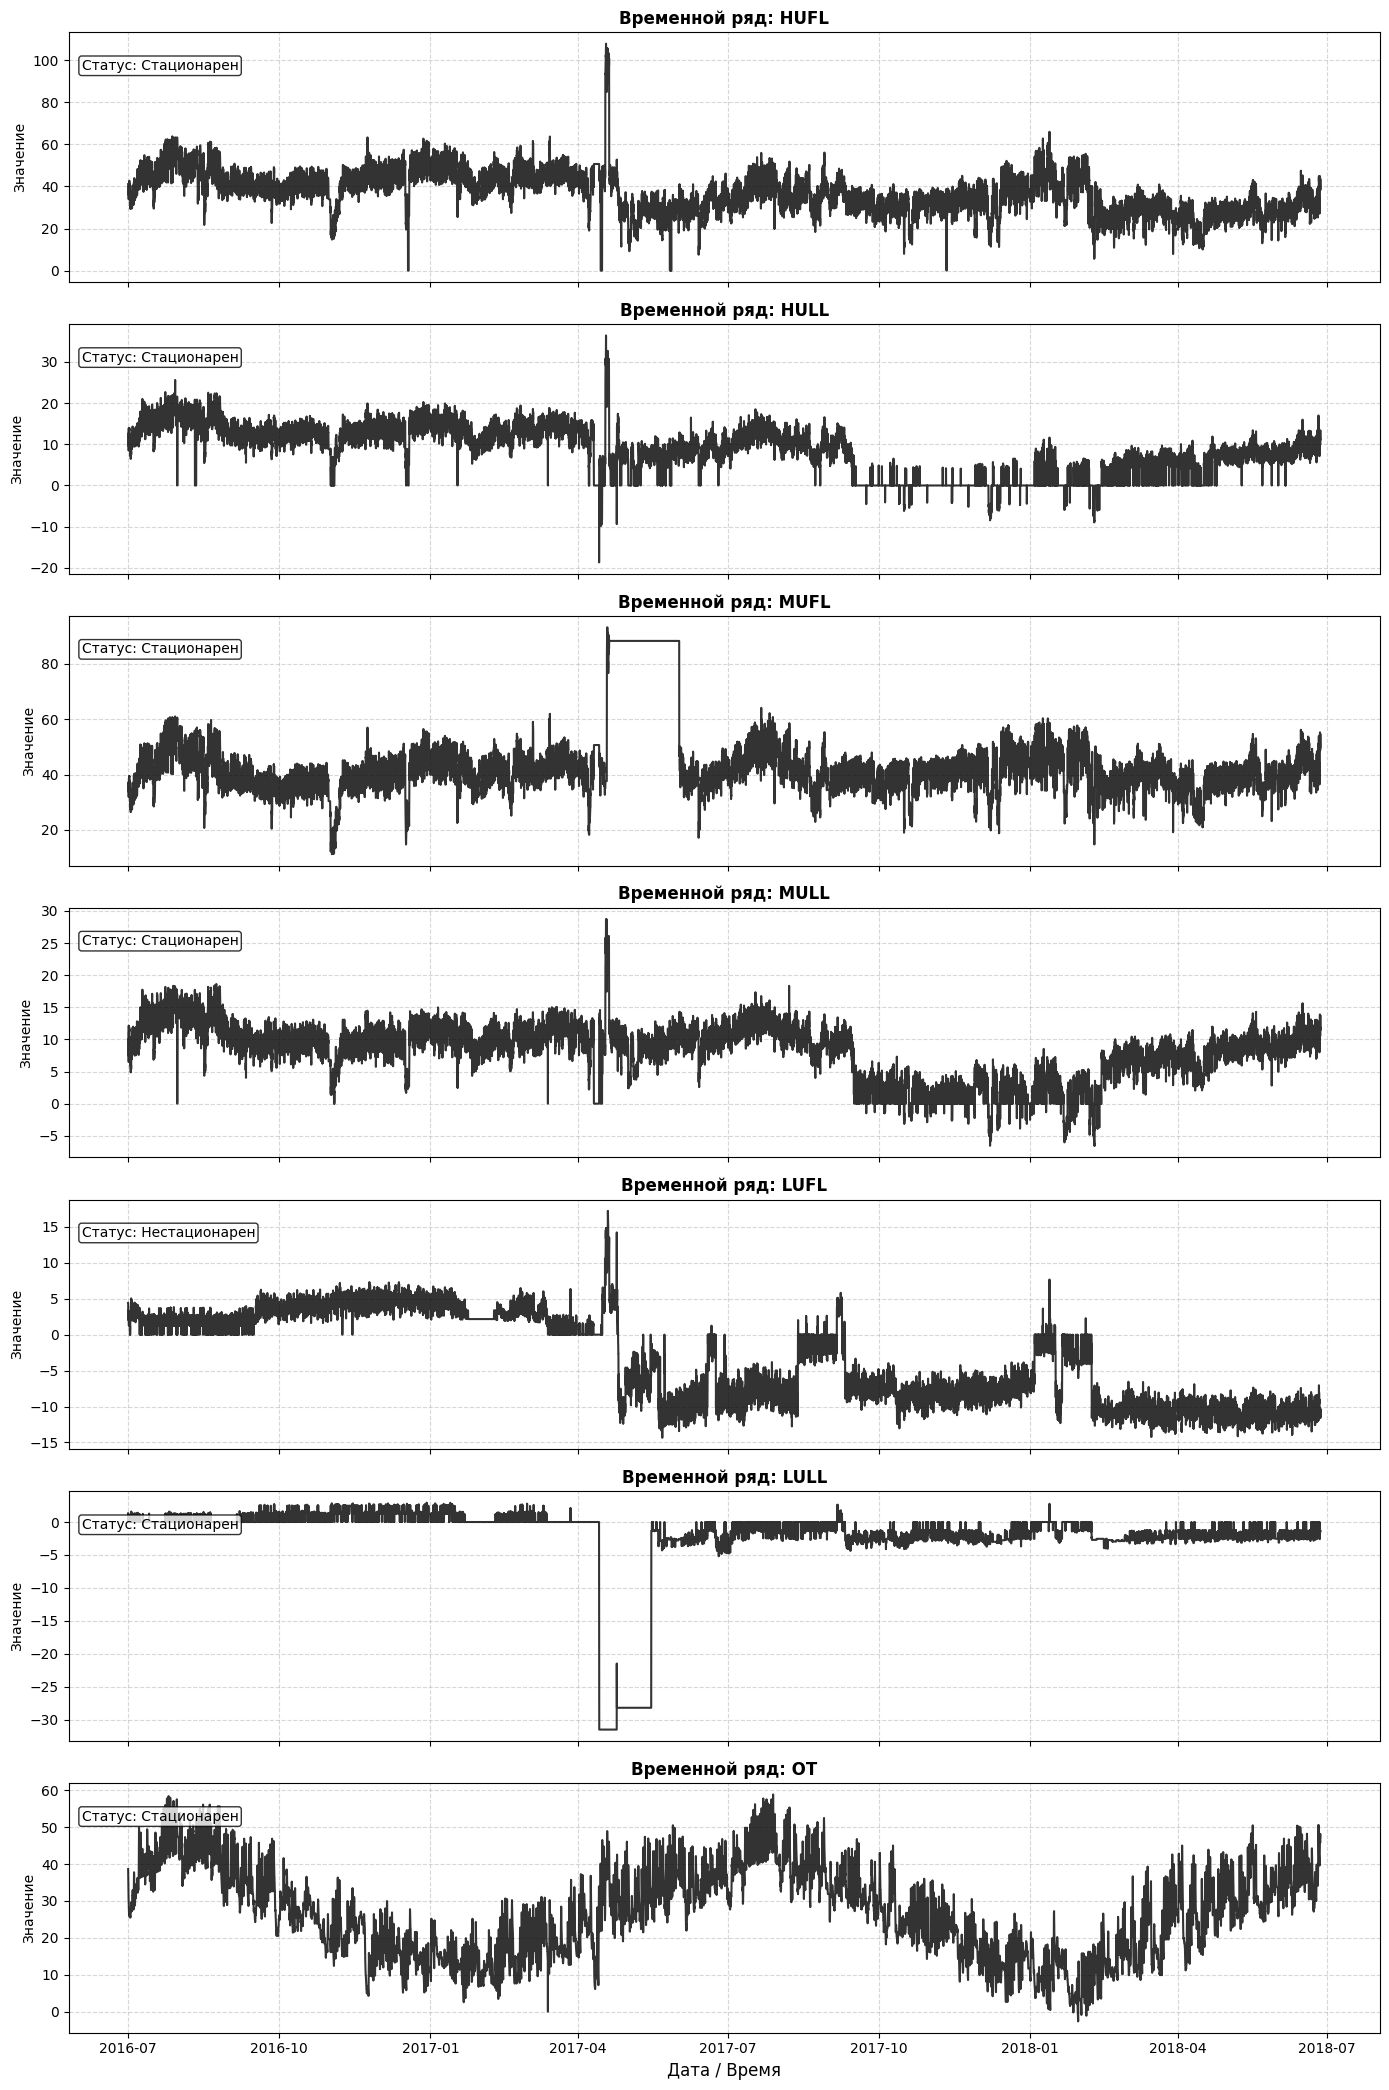

In [168]:
# 3. Визуализация всех временных рядов на отдельных графиках (в один вертикальный ряд)
print("\n=== ВИЗУАЛИЗАЦИЯ ВСЕХ ВРЕМЕННЫХ РЯДОВ ===")
num_cols = df.shape[1]

# Создаем сетку графиков: num_cols строк, 1 колонка
fig, axes = plt.subplots(nrows=num_cols, ncols=1, figsize=(14, 3 * num_cols), sharex=True)

for i, col in enumerate(df.columns):
    axes[i].plot(df.index, df[col], color='black', alpha=0.8, linewidth=1.5)
    axes[i].set_title(f"Временной ряд: {col}", fontsize=12, fontweight='bold')
    axes[i].set_ylabel("Значение", fontsize=10)
    axes[i].grid(True, linestyle='--', alpha=0.5)

    # Добавляем информацию о стационарности на график
    status = stationarity_df.loc[stationarity_df['Признак'] == col, 'Статус'].values[0]
    axes[i].text(0.01, 0.85, f"Статус: {status}", transform=axes[i].transAxes,
                 fontsize=10, bbox=dict(facecolor='white', alpha=0.8, boxstyle='round,pad=0.2'))

plt.xlabel("Дата / Время", fontsize=12)
plt.tight_layout()
plt.show()

=== ДЕКОМПОЗИЦИЯ ЦЕЛЕВОГО РЯДА (OT) НА КОМПОНЕНТЫ ===


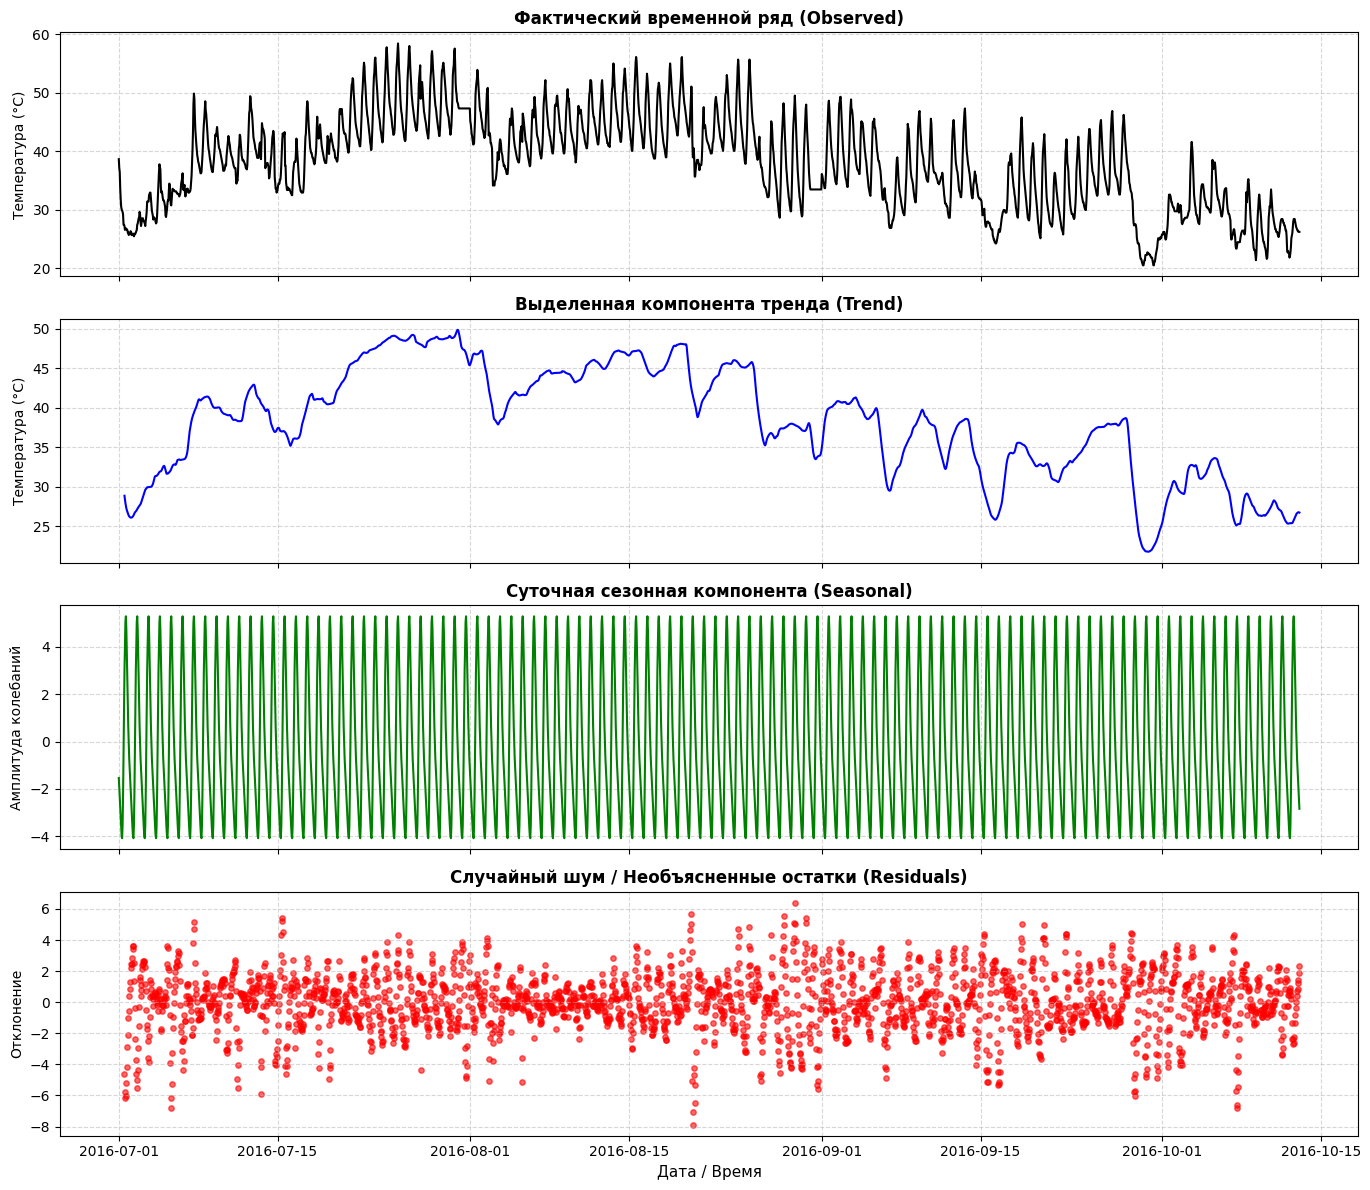

In [169]:
print("=== ДЕКОМПОЗИЦИЯ ЦЕЛЕВОГО РЯДА (OT) НА КОМПОНЕНТЫ ===")

# Выделяем целевой ряд из очищенных данных (до масштабирования, чтобы шкала оставалась в реальных градусах)
series_ot = df['OT']

# Выполняем аддитивную декомпозицию. Период 24 соответствует суточному циклу (24 часа)
decomposition = seasonal_decompose(series_ot, model='additive', period=24)

slice_hours = 2500
time_slice = series_ot.index[:slice_hours]

fig, axes = plt.subplots(nrows=4, ncols=1, figsize=(14, 12), sharex=True)

# 1. Исходный (наблюдаемый) ряд
axes[0].plot(time_slice, series_ot.iloc[:slice_hours], color='black', linewidth=1.5)
axes[0].set_title("Фактический временной ряд (Observed)", fontsize=12, fontweight='bold')
axes[0].set_ylabel("Температура (°C)")
axes[0].grid(True, linestyle='--', alpha=0.5)

# 2. Выделенный тренд
axes[1].plot(time_slice, decomposition.trend.iloc[:slice_hours], color='blue', linewidth=1.5)
axes[1].set_title("Выделенная компонента тренда (Trend)", fontsize=12, fontweight='bold')
axes[1].set_ylabel("Температура (°C)")
axes[1].grid(True, linestyle='--', alpha=0.5)

# 3. Суточная сезонность
axes[2].plot(time_slice, decomposition.seasonal.iloc[:slice_hours], color='green', linewidth=1.5)
axes[2].set_title("Суточная сезонная компонента (Seasonal)", fontsize=12, fontweight='bold')
axes[2].set_ylabel("Амплитуда колебаний")
axes[2].grid(True, linestyle='--', alpha=0.5)

# 4. Случайные остатки (шум)
axes[3].scatter(time_slice, decomposition.resid.iloc[:slice_hours], color='red', alpha=0.6, s=15)
axes[3].set_title("Случайный шум / Необъясненные остатки (Residuals)", fontsize=12, fontweight='bold')
axes[3].set_ylabel("Отклонение")
axes[3].grid(True, linestyle='--', alpha=0.5)

plt.xlabel("Дата / Время", fontsize=11)
plt.tight_layout()
plt.show()

=== АНАЛИЗ АВТОКОРРЕЛЯЦИИ (С ЛАГОМ В ОДНУ НЕДЕЛЮ) ===


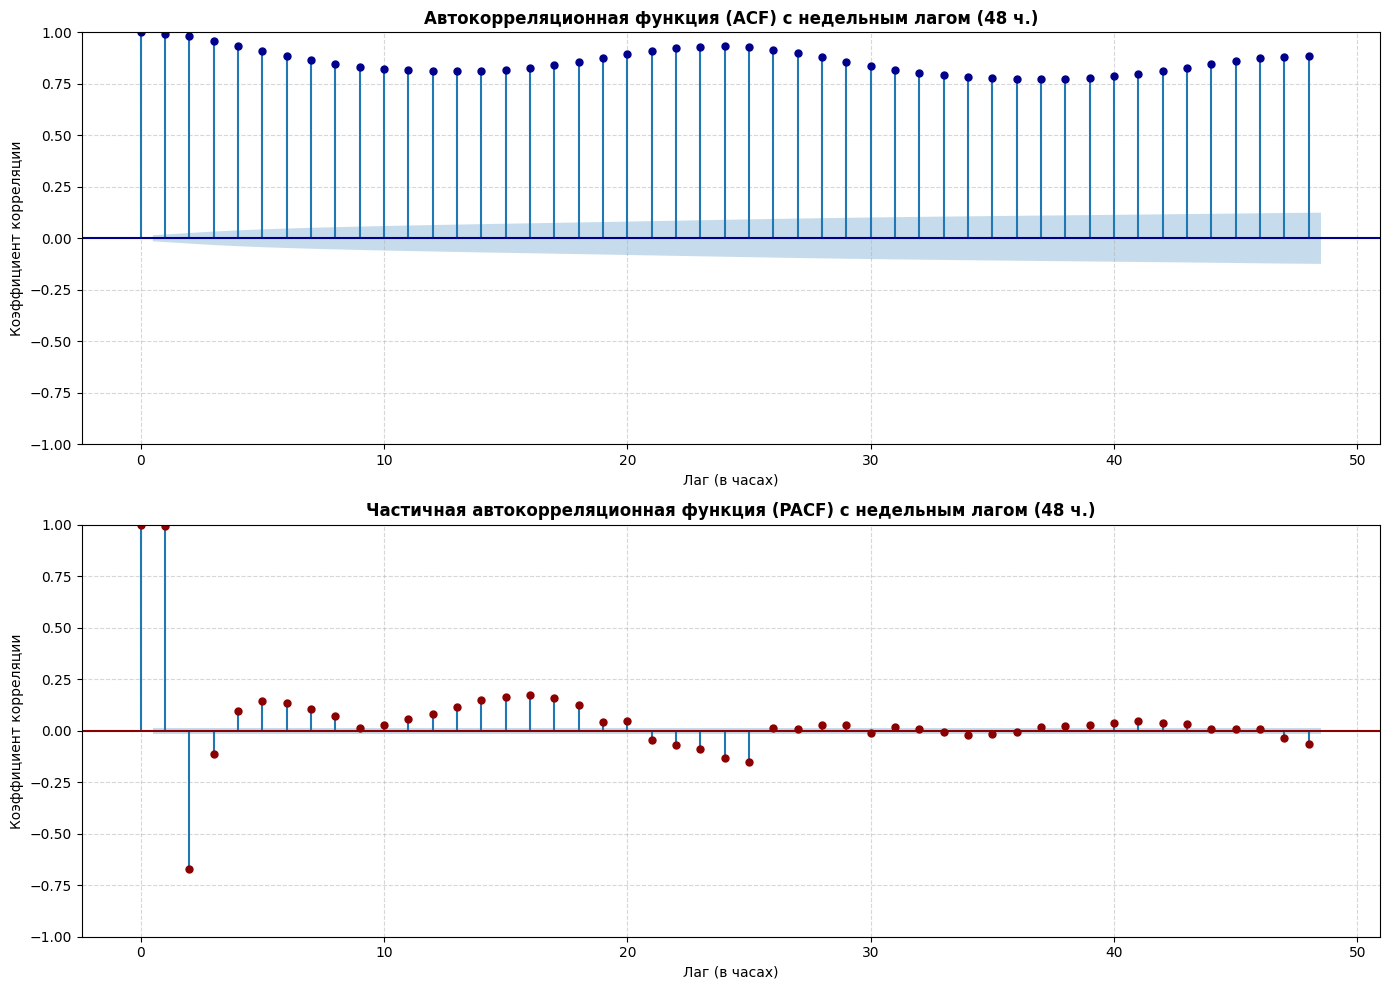

In [189]:
print("=== АНАЛИЗ АВТОКОРРЕЛЯЦИИ (С ЛАГОМ В ОДНУ НЕДЕЛЮ) ===")

# Выделяем целевой ряд
series_to_analyze = df['OT'].dropna()

lags = 48

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), sharex=False)

# 1. Автокорреляционная функция (ACF)
plot_acf(series_to_analyze, lags=lags, ax=ax1, color='darkblue')
ax1.set_title(f"Автокорреляционная функция (ACF) с недельным лагом ({lags} ч.)", fontsize=12, fontweight='bold')
ax1.set_xlabel("Лаг (в часах)")
ax1.set_ylabel("Коэффициент корреляции")
ax1.grid(True, linestyle='--', alpha=0.5)

# 2. Частичная автокорреляционная функция (PACF)
plot_pacf(series_to_analyze, lags=lags, ax=ax2, color='darkred', method='ywm')
ax2.set_title(f"Частичная автокорреляционная функция (PACF) с недельным лагом ({lags} ч.)", fontsize=12, fontweight='bold')
ax2.set_xlabel("Лаг (в часах)")
ax2.set_ylabel("Коэффициент корреляции")
ax2.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

## Предобработка временного ряда

In [171]:
# 1. Заполнение возможных пропущенных значений методом линейной интерполяции
df_clean = df.interpolate(method='linear')

In [172]:
# 2. Статистический расчет количества выбросов по методу IQR (Межквартильный размах)
print("=== СТАТИСТИЧЕСКИЙ АНАЛИЗ ВЫБРОСОВ (Метод IQR) ===")
outliers_count = {}
for col in df_clean.columns:
    q25 = df_clean[col].quantile(0.25)
    q75 = df_clean[col].quantile(0.75)
    iqr = q75 - q25
    lower_bound = q25 - 1.5 * iqr
    upper_bound = q75 + 1.5 * iqr

    # Считаем количество точек вне диапазона [lower_bound, upper_bound]
    num_outliers = ((df_clean[col] < lower_bound) | (df_clean[col] > upper_bound)).sum()
    outliers_count[col] = num_outliers
    print(f"Признак '{col}': обнаружено {num_outliers} выбросов вне границ [{lower_bound:.2f}, {upper_bound:.2f}]")

=== СТАТИСТИЧЕСКИЙ АНАЛИЗ ВЫБРОСОВ (Метод IQR) ===
Признак 'HUFL': обнаружено 124 выбросов вне границ [9.30, 64.92]
Признак 'HULL': обнаружено 73 выбросов вне границ [-8.42, 26.10]
Признак 'MUFL': обнаружено 1403 выбросов вне границ [24.37, 59.11]
Признак 'MULL': обнаружено 219 выбросов вне границ [-2.68, 19.62]
Признак 'LUFL': обнаружено 0 выбросов вне границ [-26.93, 20.20]
Признак 'LULL': обнаружено 762 выбросов вне границ [-6.26, 3.76]
Признак 'OT': обнаружено 0 выбросов вне границ [-12.21, 64.26]



=== ВИЗУАЛИЗАЦИЯ №1: ДИАГРАММЫ РАЗМАХА ДЛЯ ВСЕХ ПРИЗНАКОВ ===


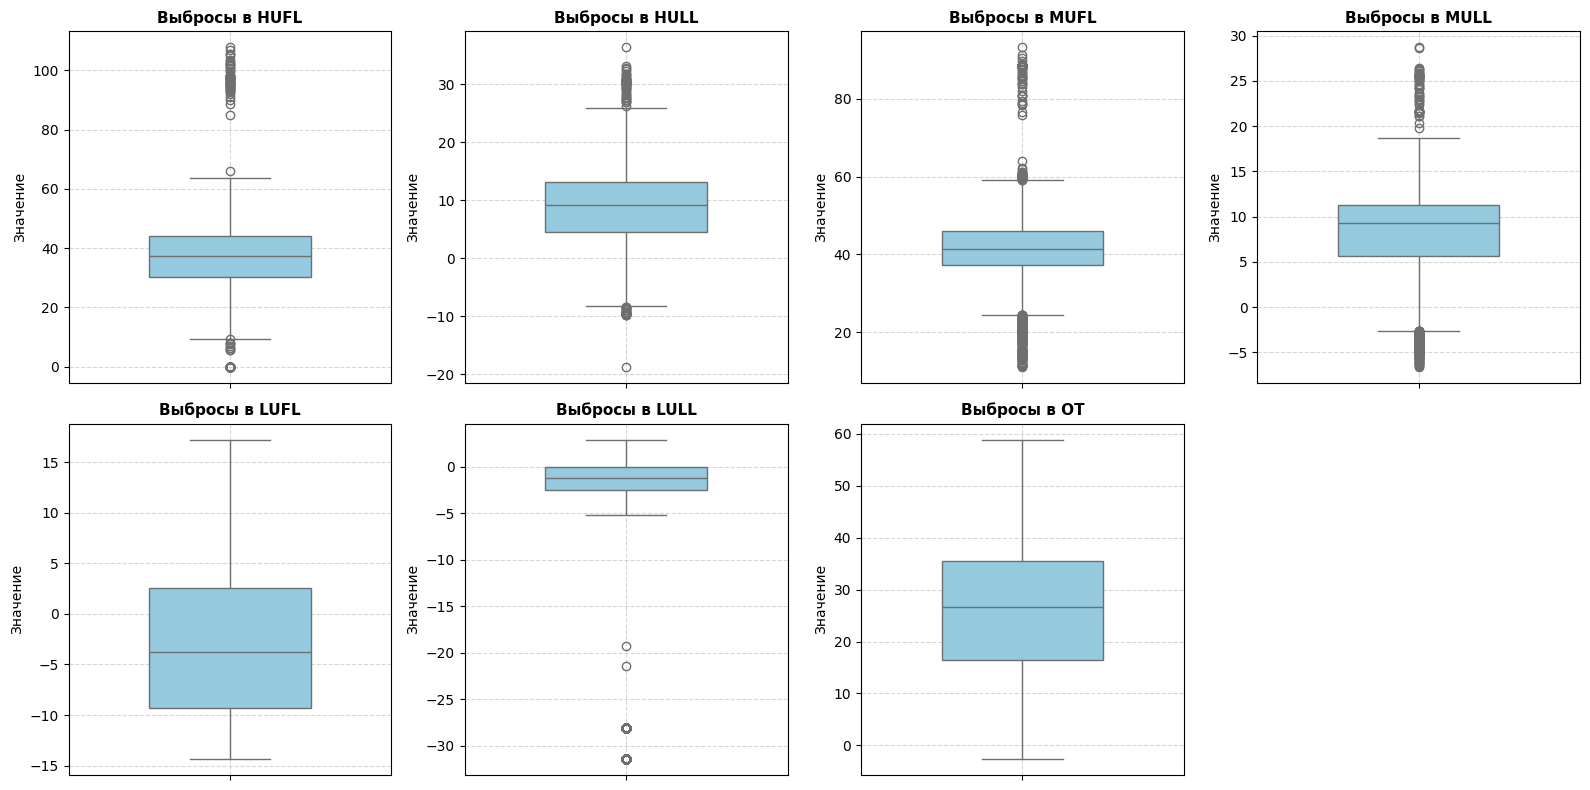

In [173]:
# 3. Визуализация №1: Диаграммы размаха (Boxplots) для всех признаков
print("\n=== ВИЗУАЛИЗАЦИЯ №1: ДИАГРАММЫ РАЗМАХА ДЛЯ ВСЕХ ПРИЗНАКОВ ===")
num_cols = df_clean.shape[1]
nrows_box = int(np.ceil(num_cols / 4)) # Размещаем по 4 графика в ряд

fig, axes = plt.subplots(nrows=nrows_box, ncols=4, figsize=(16, 4 * nrows_box))
axes = axes.flatten()

for i, col in enumerate(df_clean.columns):
    sns.boxplot(y=df_clean[col], ax=axes[i], color='skyblue', width=0.5)
    axes[i].set_title(f"Выбросы в {col}", fontsize=11, fontweight='bold')
    axes[i].set_ylabel("Значение")
    axes[i].grid(True, linestyle='--', alpha=0.5)

# Удаляем пустые графики на сетке, если они остались
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [186]:
# 4. Обработка выбросов методом межквартильного размаха (IQR - Interquartile Range)
df_clipped = df_clean.copy()
clipped_points_info = {}

# Список для сохранения результатов подсчета выбросов по каждому ряду
outliers_count_summary = []

for col in df_clean.columns:
    series = df_clean[col]

    # Шаг 1: Вычисление 25-го и 75-го квартилей, а также межквартильного размаха (IQR)
    q25 = series.quantile(0.25)
    q75 = series.quantile(0.75)
    iqr = q75 - q25

    # Шаг 2: Расчет верхнего и нижнего порогов выбросов (классический коэффициент 1.5)
    lower_limit = q25 - 1.5 * iqr
    upper_limit = q75 + 1.5 * iqr

    # Фиксация точек выбросов относительно рассчитанных границ
    is_outlier = (series < lower_limit) | (series > upper_limit)
    clipped_points_info[col] = is_outlier

    # Шаг 3: Сглаживание аномалий (усечение значений по границам IQR диапазона)
    df_clipped[col] = np.clip(series, lower_limit, upper_limit)

    # Шаг 4: Подсчет статистических показателей по выбросам
    num_outliers = is_outlier.sum()
    pct_outliers = (num_outliers / len(df_clean)) * 100

    outliers_count_summary.append({
        "Временной ряд": col,
        "Количество выбросов": num_outliers,
        "Доля от выборки (%)": round(pct_outliers, 2)
    })

# Создание и вывод сводной таблицы в Jupyter Notebook
# outliers_summary_df = pd.DataFrame(outliers_count_summary)
# print("=== СВОДНАЯ СТАТИСТИКА ВЫБРОСОВ (МЕТОД IQR) ===")
# display(outliers_summary_df)


=== ВИЗУАЛИЗАЦИЯ №2: СРАВНЕНИЕ РЯДА ДО И ПОСЛЕ ОБРАБОТКИ ВЫБРОСОВ ===


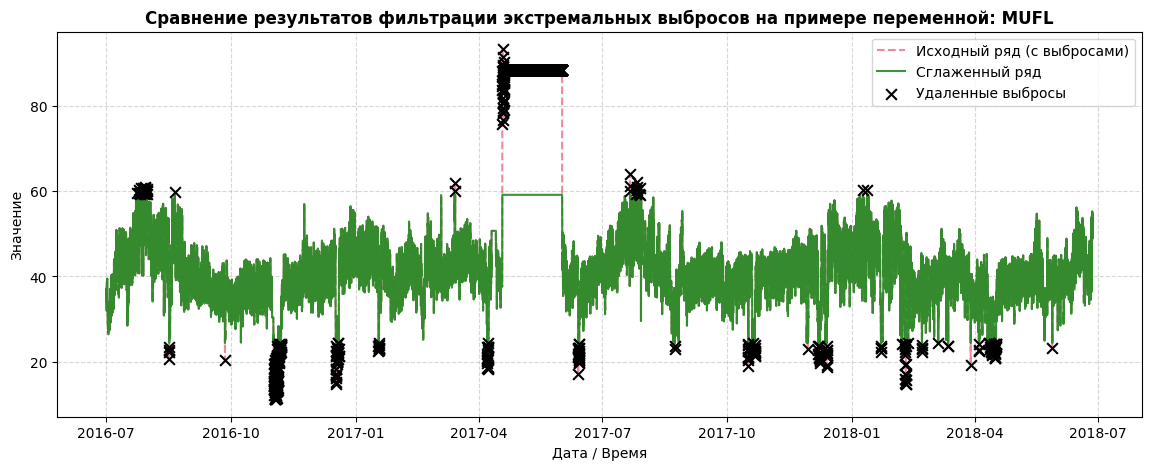

In [185]:
# 5. Визуализация №2: Сравнение временного ряда ДО и ПОСЛЕ обработки выбросов (на примере целевой переменной OT)
print("\n=== ВИЗУАЛИЗАЦИЯ №2: СРАВНЕНИЕ РЯДА ДО И ПОСЛЕ ОБРАБОТКИ ВЫБРОСОВ ===")
example_col = 'MUFL'  # Пример для целевой переменной

plt.figure(figsize=(14, 5))
# Исходный график с выбросами
plt.plot(df_clean.index, df_clean[example_col], label='Исходный ряд (с выбросами)',
         color='crimson', alpha=0.5, linestyle='--', linewidth=1.5)
# Сглаженный график
plt.plot(df_clipped.index, df_clipped[example_col], label='Сглаженный ряд',
         color='forestgreen', alpha=0.9, linewidth=1.5)

# Выделяем точки исходного ряда, которые были классифицированы как критические выбросы и усечены
outliers_idx = df_clean.index[clipped_points_info[example_col]]
outliers_val = df_clean.loc[outliers_idx, example_col]
if len(outliers_val) > 0:
    plt.scatter(outliers_idx, outliers_val, color='black', marker='x', s=60, zorder=5,
                label='Удаленные выбросы')

plt.title(f"Сравнение результатов фильтрации экстремальных выбросов на примере переменной: {example_col}", fontsize=12, fontweight='bold')
plt.xlabel("Дата / Время")
plt.ylabel("Значение")
plt.legend(loc='best')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

In [176]:
# 6. Этап кодирования (Encoding) временных циклов
# Извлекаем час суток и день недели для учета циклических закономерностей временной шкалы

df_clipped['hour'] = df_clipped.index.hour
df_clipped['dayofweek'] = df_clipped.index.dayofweek

# Переводим час в циклическое синусно-косинусное представление
df_clipped['hour_sin'] = np.sin(2 * np.pi * df_clipped['hour'] / 24.0)
df_clipped['hour_cos'] = np.cos(2 * np.pi * df_clipped['hour'] / 24.0)

# Переводим день недели в аналогичное представление
df_clipped['day_sin'] = np.sin(2 * np.pi * df_clipped['dayofweek'] / 7.0)
df_clipped['day_cos'] = np.cos(2 * np.pi * df_clipped['dayofweek'] / 7.0)

# Удаляем исходные линейные временные колонки, оставляя закодированные признаки
df_clipped.drop(columns=['hour', 'dayofweek'], inplace=True)

In [177]:
# 7. Масштабирование признаков (StandardScaler) на основе очищенных данных
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df_clipped)
df_scaled = pd.DataFrame(scaled_data, columns=df_clipped.columns, index=df_clipped.index)

print("Предобработка, включая этап кодирования циклических признаков, успешно завершена.")
df_scaled.head()

Предобработка, включая этап кодирования циклических признаков, успешно завершена.


,HUFL,HULL,MUFL,MULL,LUFL,LULL,OT,hour_sin,hour_cos,day_sin,day_cos
date,,,,,,,,,,,
2016-07-01 00:00:00,0.415526,0.660802,-0.728784,0.241134,1.277232,1.276865,1.013854,-0.000189,1.414495,-0.610741,-1.275875
2016-07-01 01:00:00,0.042183,0.268690,-1.067370,-0.184756,1.279023,1.225606,0.884479,0.365827,1.366306,-0.610741,-1.275875
2016-07-01 02:00:00,0.085612,0.464830,-0.885835,0.159834,0.898991,0.576863,0.829045,0.706900,1.225022,-0.610741,-1.275875
2016-07-01 03:00:00,0.189779,0.562816,-0.857968,0.260057,1.107317,1.225606,0.588759,0.999786,1.000272,-0.610741,-1.275875
2016-07-01 04:00:00,0.102921,0.492754,-0.875418,0.303744,0.888575,0.576863,0.440878,1.224525,0.707371,-0.610741,-1.275875


## Извлечение признаков

In [178]:
df_features = df_scaled.copy()

# Метод 1: Извлечение расширенного набора лагов (Lag Features) целевой переменной OT
lags_list = [1, 2, 3, 6, 12, 24]
for lag in lags_list:
    df_features[f'OT_lag_{lag}'] = df_features['OT'].shift(lag)

# Метод 2: Скользящие статистики для двух вариантов окон (6 и 24)
window_short = 6
window_long = 24

if len(df_features) <= window_long:
    window_short = 2
    window_long = 4

# Скользящие статистики для короткого окна
df_features[f'OT_roll_mean_{window_short}'] = df_features['OT'].rolling(window=window_short).mean()
df_features[f'OT_roll_std_{window_short}'] = df_features['OT'].rolling(window=window_short).std()

# Скользящие статистики для длинного окна
df_features[f'OT_roll_mean_{window_long}'] = df_features['OT'].rolling(window=window_long).mean()
df_features[f'OT_roll_std_{window_long}'] = df_features['OT'].rolling(window=window_long).std()

# Метод 3: Извлечение признаков быстрого преобразования Фурье (FFT Features)
# Анализируем частотную область в скользящем временном окне для фиксации скрытых гармоник
fft_window_size = window_long

def get_sliding_fft_features(data_array, window):
    freq1_mags = []
    freq2_mags = []
    for i in range(len(data_array)):
        if i < window - 1:
            freq1_mags.append(np.nan)
            freq2_mags.append(np.nan)
        else:
            slice_data = data_array[i - window + 1 : i + 1]
            # Быстрое преобразование Фурье
            fft_complex = np.fft.fft(slice_data)
            fft_abs = np.abs(fft_complex)
            # Извлекаем амплитуды первых двух гармоник после постоянной составляющей (DC offset)
            freq1_mags.append(fft_abs[1] if len(fft_abs) > 1 else 0.0)
            freq2_mags.append(fft_abs[2] if len(fft_abs) > 2 else 0.0)
    return freq1_mags, freq2_mags

f1, f2 = get_sliding_fft_features(df_features['OT'].values, fft_window_size)
df_features['OT_fft_freq1'] = f1
df_features['OT_fft_freq2'] = f2

# Удаление пустых значений (NaN), возникших при расчете лагов, окон и FFT
df_features.dropna(inplace=True)

print(f"Извлечение признаков завершено. Итоговая размерность пространства признаков: {df_features.shape}")
df_features.head()

Извлечение признаков завершено. Итоговая размерность пространства признаков: (17396, 23)


,HUFL,HULL,MUFL,MULL,LUFL,LULL,OT,hour_sin,hour_cos,day_sin,...,OT_lag_3,OT_lag_6,OT_lag_12,OT_lag_24,OT_roll_mean_6,OT_roll_std_6,OT_roll_mean_24,OT_roll_std_24,OT_fft_freq1,OT_fft_freq2
date,,,,,,,,,,,,,,,,,,,,,
2016-07-02 00:00:00,-0.157548,0.492754,-1.098755,0.366355,0.807035,0.576863,-0.058158,-0.000189,1.414495,-1.376062,...,-0.076622,-0.002681,0.052753,1.013854,-0.055080,0.013899,0.167490,0.276144,3.249496,1.873063
2016-07-02 01:00:00,-0.435327,0.240599,-1.283805,0.115914,0.557207,0.576863,-0.021188,0.365827,1.366306,-1.376062,...,-0.058158,-0.039694,-0.002723,0.884479,-0.051996,0.019083,0.129753,0.232307,2.726809,1.581436
2016-07-02 02:00:00,-0.600336,0.170704,-1.535141,0.040688,0.557207,0.576863,-0.039694,0.706900,1.225022,-1.376062,...,-0.058158,-0.039694,0.015783,0.829045,-0.051996,0.019083,0.093556,0.180517,2.229619,1.315000
2016-07-02 03:00:00,-0.669781,0.114521,-1.601426,-0.015615,0.557207,0.576863,-0.076622,0.999786,1.000272,-1.376062,...,-0.058158,-0.076622,0.015783,0.588759,-0.051996,0.019083,0.065832,0.149605,1.860119,1.133897
2016-07-02 04:00:00,-0.652368,0.100642,-1.611974,-0.071917,0.754953,0.576863,-0.076622,1.224525,0.707371,-1.376062,...,-0.021188,-0.058158,0.015783,0.440878,-0.055073,0.021599,0.044269,0.129085,1.573440,0.982965


## Разделение данных и создание скользящего окна

In [179]:
target_col = 'OT'
feature_cols = [col for col in df_features.columns if col != target_col]

X_data = df_features[feature_cols].values
y_data = df_features[target_col].values

# Формирование трехмерных последовательностей
def create_sequences(X, y, seq_len):
    X_seq, y_seq = [], []
    for i in range(len(X) - seq_len):
        X_seq.append(X[i:(i + seq_len)])
        y_seq.append(y[i + seq_len])
    return np.array(X_seq), np.array(y_seq)

# Устанавливаем суточный шаг предыстории (24 часа)
SEQ_LEN = 24
X_3D, y_3D = create_sequences(X_data, y_data, seq_len=SEQ_LEN)

# Хронологическое разделение в пропорции 70% (Train) / 15% (Val) / 15% (Test)
train_split = int(len(X_3D) * 0.70)
val_split = int(len(X_3D) * 0.85)

# Формирование трехмерных выборок для нейросетей (LSTM, CNN1D)
X_train_3D = X_3D[:train_split]
y_train = y_3D[:train_split]

X_val_3D = X_3D[train_split:val_split]
y_val = y_3D[train_split:val_split]

X_test_3D = X_3D[val_split:]
y_test = y_3D[val_split:]

# Преобразование трехмерных массивов в двумерные для классического ML (Random Forest)
X_train_2D = X_train_3D.reshape(X_train_3D.shape[0], -1)
X_val_2D = X_val_3D.reshape(X_val_3D.shape[0], -1)
X_test_2D = X_test_3D.reshape(X_test_3D.shape[0], -1)

print(f"Обучающая выборка (3D): {X_train_3D.shape}")
print(f"Валидационная выборка (3D): {X_val_3D.shape}")
print(f"Тестовая выборка (3D):  {X_test_3D.shape}")
print(f"Обучающая выборка (2D): {X_train_2D.shape}")

Обучающая выборка (3D): (12160, 24, 22)
Валидационная выборка (3D): (2606, 24, 22)
Тестовая выборка (3D):  (2606, 24, 22)
Обучающая выборка (2D): (12160, 528)


## Random Forest Regressor

In [180]:
# Инициализация и обучение регрессора случайного леса с оптимизацией для больших данных
rf_model = RandomForestRegressor(
    n_estimators=50,
    max_depth=12,
    max_features='sqrt',
    min_samples_leaf=4,
    n_jobs=-1,
    random_state=42
)

print("=== Начинается обучение Random Forest (оптимизированная версия) ===")
rf_model.fit(X_train_2D, y_train)
print("Обучение завершено.")

# Вычисление прогноза на тестовой выборке
rf_pred = rf_model.predict(X_test_2D)

# Оценка метрик эффективности
rf_mse = mean_squared_error(y_test, rf_pred)
rf_mae = mean_absolute_error(y_test, rf_pred)
rf_r2 = r2_score(y_test, rf_pred)

print("\n=== Результаты классического машинного обучения (Random Forest) ===")
print(f"MSE: {rf_mse:.5f}")
print(f"MAE: {rf_mae:.5f}")
print(f"R²:  {rf_r2:.5f}")

=== Начинается обучение Random Forest (оптимизированная версия) ===
Обучение завершено.

=== Результаты классического машинного обучения (Random Forest) ===
MSE: 0.03216
MAE: 0.12322
R²:  0.93419


## Вспомогательные функции для PyTorch

In [181]:
# Определение устройства (GPU, если доступно, иначе CPU)
device = torch.device('cpu')

# Создание PyTorch тензоров для трех выборок
train_dataset = TensorDataset(torch.tensor(X_train_3D, dtype=torch.float32),
                              torch.tensor(y_train, dtype=torch.float32).unsqueeze(1))
val_dataset = TensorDataset(torch.tensor(X_val_3D, dtype=torch.float32),
                            torch.tensor(y_val, dtype=torch.float32).unsqueeze(1))
test_dataset = TensorDataset(torch.tensor(X_test_3D, dtype=torch.float32),
                             torch.tensor(y_test, dtype=torch.float32).unsqueeze(1))

# Загрузчики данных с оптимальным размером батча (batch_size=64) для 17к строк
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=False)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

def train_nn_model(model, train_loader, val_loader, epochs=30, lr=0.001):
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    model = model.to(device)
    for epoch in range(epochs):
        model.train()
        train_loss = 0.0
        for batch_X, batch_y in train_loader:
            batch_X, batch_y = batch_X.to(device), batch_y.to(device)
            optimizer.zero_grad()
            predictions = model(batch_X)
            loss = criterion(predictions, batch_y)
            loss.backward()
            optimizer.step()
            train_loss += loss.item() * batch_X.size(0)

        # Расчет ошибки на валидационной выборке в конце каждой эпохи
        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for batch_X, batch_y in val_loader:
                batch_X, batch_y = batch_X.to(device), batch_y.to(device)
                preds = model(batch_X)
                loss = criterion(preds, batch_y)
                val_loss += loss.item() * batch_X.size(0)

        train_loss /= len(train_loader.dataset)
        val_loss /= len(val_loader.dataset)

        # Вывод прогресса каждые 5 эпох
        if (epoch + 1) % 5 == 0 or epoch == 0:
            print(f"Эпоха [{epoch+1}/{epochs}] | Train Loss: {train_loss:.5f} | Val Loss: {val_loss:.5f}")

    return model

def evaluate_nn_model(model, test_loader):
    model.eval()
    model = model.to(device)
    predictions, targets = [], []
    with torch.no_grad():
        for batch_X, batch_y in test_loader:
            batch_X = batch_X.to(device)
            preds = model(batch_X)
            predictions.append(preds.cpu().numpy())  # Возвращаем тензор на CPU для конвертации в numpy
            targets.append(batch_y.numpy())

    predictions = np.vstack(predictions).flatten()
    targets = np.vstack(targets).flatten()

    mse = mean_squared_error(targets, predictions)
    mae = mean_absolute_error(targets, predictions)
    r2 = r2_score(targets, predictions)
    return mse, mae, r2, predictions

## Нейросеть №1 (LSTM)

In [182]:
class LSTMRegressor(nn.Module):
    def __init__(self, input_size, hidden_size=64, num_layers=2):
        super(LSTMRegressor, self).__init__()
        # Двухслойная LSTM с регуляризацией dropout
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers=num_layers, batch_first=True, dropout=0.2)
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        # x shape: [batch, seq_len, input_size]
        out, (hn, cn) = self.lstm(x)
        # Извлекаем последнее состояние из последовательности
        out = out[:, -1, :]
        out = self.fc(out)
        return out

# Инициализация и запуск обучения на GPU/CPU
input_dim = X_train_3D.shape[2]
lstm_model = LSTMRegressor(input_size=input_dim)

print("=== Начинается обучение LSTM ===")
lstm_model = train_nn_model(lstm_model, train_loader, val_loader, epochs=30, lr=0.001)

# Вычисление финальных метрик на тестовой выборке
lstm_mse, lstm_mae, lstm_r2, lstm_pred = evaluate_nn_model(lstm_model, test_loader)

print("\n=== Финальные результаты LSTM на тестовой выборке ===")
print(f"MSE: {lstm_mse:.5f}")
print(f"MAE: {lstm_mae:.5f}")
print(f"R²:  {lstm_r2:.5f}")

=== Начинается обучение LSTM ===
Эпоха [1/30] | Train Loss: 0.25769 | Val Loss: 0.48562
Эпоха [5/30] | Train Loss: 0.03799 | Val Loss: 0.11669
Эпоха [10/30] | Train Loss: 0.01983 | Val Loss: 0.06669
Эпоха [15/30] | Train Loss: 0.01655 | Val Loss: 0.04207
Эпоха [20/30] | Train Loss: 0.01469 | Val Loss: 0.05268
Эпоха [25/30] | Train Loss: 0.01311 | Val Loss: 0.03335
Эпоха [30/30] | Train Loss: 0.01146 | Val Loss: 0.03613

=== Финальные результаты LSTM на тестовой выборке ===
MSE: 0.01324
MAE: 0.08738
R²:  0.97290


## Нейросеть №2 (CNN1D)

In [183]:
class CNN1DRegressor(nn.Module):
    def __init__(self, input_size):
        super(CNN1DRegressor, self).__init__()
        # Использование ядра 3 с паддингом для сохранения временного измерения
        self.conv1 = nn.Conv1d(in_channels=input_size, out_channels=32, kernel_size=3, padding=1)
        self.relu = nn.ReLU()
        self.fc = nn.Linear(32, 1)

    def forward(self, x):
        # Приведение тензора к размерности [batch, input_size, seq_len]
        x = x.transpose(1, 2)
        x = self.conv1(x)
        x = self.relu(x)
        # Глобальный Pooling по временной оси (теперь работает на окне 24)
        x = torch.max(x, dim=2)[0]
        x = self.fc(x)
        return x

# Инициализация и обучение CNN1D
cnn_model = CNN1DRegressor(input_size=input_dim)

print("=== Начинается обучение CNN1D ===")
cnn_model = train_nn_model(cnn_model, train_loader, val_loader, epochs=30, lr=0.001)

# Тестирование сверточной сети
cnn_mse, cnn_mae, cnn_r2, cnn_pred = evaluate_nn_model(cnn_model, test_loader)

print("\n=== Финальные результаты CNN1D на тестовой выборке ===")
print(f"MSE: {cnn_mse:.5f}")
print(f"MAE: {cnn_mae:.5f}")
print(f"R²:  {cnn_r2:.5f}")

=== Начинается обучение CNN1D ===
Эпоха [1/30] | Train Loss: 0.21863 | Val Loss: 0.09120
Эпоха [5/30] | Train Loss: 0.03768 | Val Loss: 0.04310
Эпоха [10/30] | Train Loss: 0.02414 | Val Loss: 0.04190
Эпоха [15/30] | Train Loss: 0.02030 | Val Loss: 0.04254
Эпоха [20/30] | Train Loss: 0.01899 | Val Loss: 0.03612
Эпоха [25/30] | Train Loss: 0.01921 | Val Loss: 0.02610
Эпоха [30/30] | Train Loss: 0.02104 | Val Loss: 0.02200

=== Финальные результаты CNN1D на тестовой выборке ===
MSE: 0.03371
MAE: 0.14192
R²:  0.93101


## Анализ результатов и выводы

,Модель,MSE (Ниже - лучше),MAE (Ниже - лучше),R² (Выше - лучше)
0,Random Forest (ML),0.032165,0.123221,0.934185
1,LSTM (RNN),0.013244,0.087380,0.972900
2,CNN1D,0.033715,0.141917,0.931014



Наилучшие результаты по метрике MSE показывает модель: LSTM (RNN)


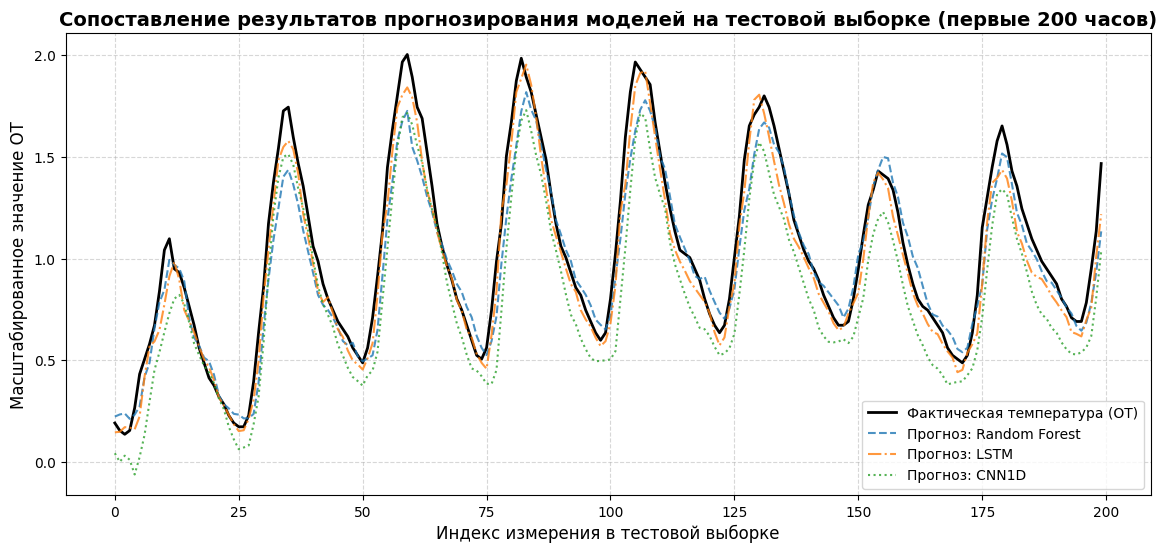

In [184]:
# Построение итоговой сравнительной таблицы по метрикам MSE, MAE и R² на тестовой выборке
summary_data = {
    "Модель": ["Random Forest (ML)", "LSTM (RNN)", "CNN1D"],
    "MSE (Ниже - лучше)": [rf_mse, lstm_mse, cnn_mse],
    "MAE (Ниже - лучше)": [rf_mae, lstm_mae, cnn_mae],
    "R² (Выше - лучше)": [rf_r2, lstm_r2, cnn_r2]
}

summary_df = pd.DataFrame(summary_data)
display(summary_df)

# Нахождение лучшей модели
best_model_name = summary_df.loc[summary_df['MSE (Ниже - лучше)'].idxmin(), 'Модель']
print(f"\nНаилучшие результаты по метрике MSE показывает модель: {best_model_name}")

# График сравнения прогнозов (отобразим первые 200 часов тестового интервала)
n_sampmes = y_test.shape[0]

plt.figure(figsize=(14, 6))
plt.plot(y_test[n_sampmes-400:n_sampmes-200], label="Фактическая температура (OT)", color='black', linewidth=2.0)
plt.plot(rf_pred[n_sampmes-400:n_sampmes-200], label="Прогноз: Random Forest", linestyle='--', alpha=0.8)
plt.plot(lstm_pred[n_sampmes-400:n_sampmes-200], label="Прогноз: LSTM", linestyle='-.', alpha=0.8)
plt.plot(cnn_pred[n_sampmes-400:n_sampmes-200], label="Прогноз: CNN1D", linestyle=':', alpha=0.8)

plt.title("Сопоставление результатов прогнозирования моделей на тестовой выборке (первые 200 часов)", fontsize=14, fontweight='bold')
plt.xlabel("Индекс измерения в тестовой выборке", fontsize=12)
plt.ylabel("Масштабированное значение OT", fontsize=12)
plt.legend(fontsize=10)
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()